In [1]:
import os
os.listdir()

['.ipynb_checkpoints',
 'fear_greed_index.csv',
 'historical_data.csv',
 'Trader_Sentiment_Analysis.ipynb']

# Trader Behavior Analysis Based on Market Sentiment

## Objective
The goal of this project is to analyze how trader performance and behavior change 
across different market sentiment regimes (Fear vs Greed).

We aim to:
- Compare profitability across sentiment categories
- Evaluate win rate differences
- Analyze trade size and frequency patterns
- Derive behavioral insights
- Suggest strategy improvements

# Part A — Data preparation

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

## Data Loading

We load two datasets:

1. Historical Trade Data – Contains trade-level information such as timestamp, PnL, position size, etc.
2. Fear & Greed Index Data – Contains daily market sentiment classification.

The datasets will later be merged using the trade date.

In [6]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

print("Trades shape:", trades.shape)
print("Sentiment shape:", sentiment.shape)


Trades shape: (211224, 16)
Sentiment shape: (2644, 4)


In [7]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [8]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


## Data Cleaning

The following cleaning steps are performed:

- Converted timestamp columns to datetime format
- Extracted trade date
- Standardized sentiment dates
- Removed missing classification values
- Ensured correct data types

In [10]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True)
trades['date'] = trades['Timestamp IST'].dt.date
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date
sentiment = sentiment.dropna(subset=['classification'])


## Feature Engineering

- Merge trade data with sentiment
- Create win/loss indicator
- Prepare dataset for analysis

In [12]:
df = trades.merge(sentiment[['date', 'classification']],
    on='date',
    how='left'
)

df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [13]:
df['classification'].isnull().sum()

6

In [14]:
df = df.dropna(subset=['classification'])

#### Daily PnL per Trader


In [16]:
daily_pnl = df.groupby(
    ['Account','date','classification']
)['Closed PnL'].sum().reset_index()

daily_pnl.head()

,Account,date,classification,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Extreme Greed,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Extreme Greed,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Extreme Greed,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Extreme Greed,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Extreme Greed,1603.1


#### Win Rate


In [18]:
df['win'] = df['Closed PnL'] > 0

win_rate = df.groupby(
    ['classification']
)['win'].mean().reset_index()

win_rate

,classification,win
0,Extreme Fear,0.370607
1,Extreme Greed,0.464943
2,Fear,0.420768
3,Greed,0.384828
4,Neutral,0.396991


#### Average Trade Size

In [20]:
avg_size = df.groupby(
    ['classification']
)['Size USD'].mean().reset_index()

avg_size

,classification,Size USD
0,Extreme Fear,5349.731843
1,Extreme Greed,3112.251565
2,Fear,7816.109931
3,Greed,5736.884375
4,Neutral,4782.732661


#### Trades per Day

In [22]:
trade_freq = df.groupby(
    ['date','classification']
).size().reset_index(name='trade_count')

trade_freq.head()

,date,classification,trade_count
0,2023-05-01,Greed,3
1,2023-12-05,Extreme Greed,9
2,2023-12-14,Greed,11
3,2023-12-15,Greed,2
4,2023-12-16,Greed,3


### PLOT 1 — PnL Fear vs Greed

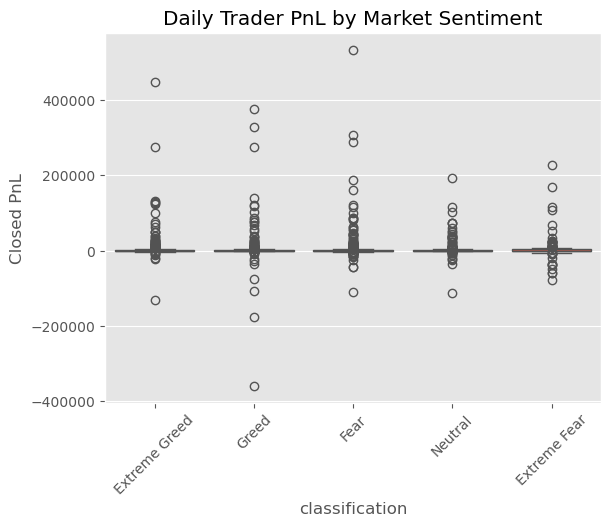

In [24]:
sns.boxplot(data=daily_pnl, x='classification', y='Closed PnL')
plt.xticks(rotation=45)
plt.title("Daily Trader PnL by Market Sentiment")
plt.show()

### Insight 1 — PnL Volatility Increases During Extreme Sentiment

Trader PnL shows significantly wider dispersion during Extreme Fear and Extreme Greed days. 
This indicates higher volatility and risk-taking behavior when market emotions are intense.

Both large profits and large losses occur more frequently during extreme sentiment regimes, 
suggesting emotional markets amplify trading outcomes.

### PLOT 2 — Win Rate

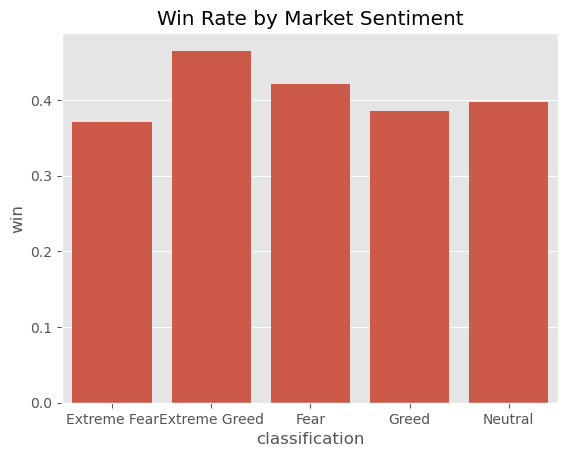

In [27]:
sns.barplot(data=win_rate, x='classification', y='win')
plt.title("Win Rate by Market Sentiment")
plt.show()

### Insight 2 — Win Rate Improves During Greed, Drops in Extreme Fear

Win rate is highest during Extreme Greed and lowest during Extreme Fear.
This suggests traders perform better in optimistic markets and struggle during panic-driven conditions.

Extreme Fear appears to reduce trading accuracy, possibly due to overreaction or poor timing.

### PLOT 3 — Trade Size

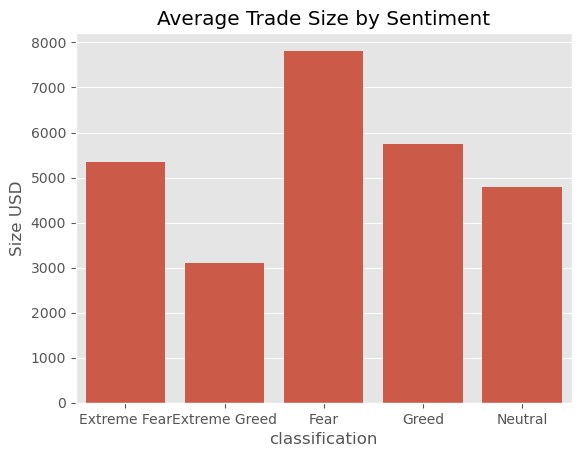

In [30]:
sns.barplot(data=avg_size, x='classification', y='Size USD')
plt.title("Average Trade Size by Sentiment")
plt.show()

### Insight 3 — Traders Increase Position Size During Fear

Average trade size is highest during Fear periods.
Interestingly, this does not correspond to the highest win rate.

This suggests traders increase exposure during uncertain conditions,
potentially reflecting overconfidence or reactive trading behavior.

### PLOT 4 — Trade Frequency

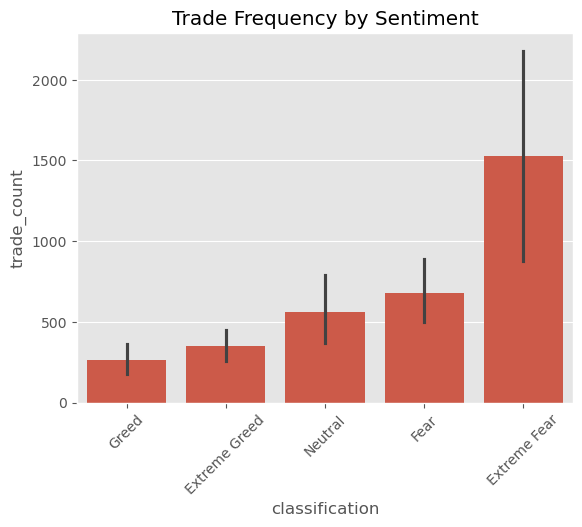

In [33]:
sns.barplot(data=trade_freq, x='classification', y='trade_count')
plt.title("Trade Frequency by Sentiment")
plt.xticks(rotation=45)
plt.show()

### Insight 4 — Trade Frequency Spikes During Extreme Fear

Trade activity is highest during Extreme Fear periods.
This indicates overtrading behavior during panic-driven markets.

In contrast, trade frequency is lowest during Greed regimes,
suggesting more selective and controlled participation.

# Part B — Analysis

Q1 — Does performance differ between Fear vs Greed?

YES.
Win rate is higher in Greed.
Extreme Fear has lowest win rate.
PnL volatility is higher during extreme emotions.


Q2 — Do traders change behavior based on sentiment?

YES clearly:
Trade frequency spikes in Extreme Fear.
Trade size increases in Fear.
Win rate improves in Extreme Greed.
Overtrading happens during panic.

##### High vs Low Activity Traders

In [38]:
trader_activity = df.groupby('Account').size().reset_index(name='total_trades')

median_trades = trader_activity['total_trades'].median()

trader_activity['segment'] = np.where(
    trader_activity['total_trades'] > median_trades,
    'High Activity',
    'Low Activity'
)

trader_activity.head()

,Account,total_trades,segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,High Activity
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,High Activity
2,0x271b280974205ca63b716753467d5a371de622ab,3809,High Activity
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,High Activity
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,Low Activity


In [39]:
df = df.merge(trader_activity[['Account','segment']], on='Account')

In [40]:
segment_pnl = df.groupby(
    ['segment','classification']
)['Closed PnL'].mean().reset_index()

segment_pnl

,segment,classification,Closed PnL
0,High Activity,Extreme Fear,34.163353
1,High Activity,Extreme Greed,62.870911
2,High Activity,Fear,51.323784
3,High Activity,Greed,25.004641
4,High Activity,Neutral,34.579701
5,Low Activity,Extreme Fear,35.941979
6,Low Activity,Extreme Greed,103.264685
7,Low Activity,Fear,80.835791
8,Low Activity,Greed,210.210287
9,Low Activity,Neutral,31.845656


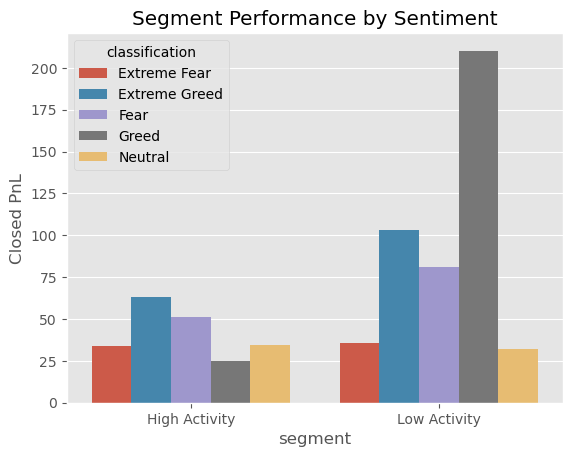

In [41]:
sns.barplot(data=segment_pnl, x='segment', y='Closed PnL', hue='classification')
plt.title("Segment Performance by Sentiment")
plt.show()

## Strategy Recommendations

1. During Extreme Fear, reduce leverage and avoid high trade frequency.
   The data shows overtrading and lower win rates in panic conditions.

2. During Extreme Greed, maintain moderate position sizing as win rate improves.
   However, monitor for volatility spikes due to emotional overextension.

3. Implement position size controls during Fear regimes,
   as traders tend to increase exposure without corresponding performance improvement.

# Part C — “Actionable output”

## Strategy Idea 1 — Risk Control During Extreme Fear

Data shows that during Extreme Fear periods:
- Trade frequency spikes
- Win rate declines
- PnL volatility increases

This suggests emotionally driven overtrading.

Actionable Rule:
- Reduce leverage by 25–40% during Extreme Fear days.
- Limit maximum number of trades per day.
- Apply stricter stop-loss thresholds.

This helps control drawdowns during panic-driven markets.

## Strategy Idea 2 — Controlled Expansion During Extreme Greed

Data shows that win rate improves during Extreme Greed periods.

This suggests market conditions may favor trend continuation strategies.

Actionable Rule:
- Allow slightly higher position sizing (10–20%) during Extreme Greed.
- Focus on momentum-based trades.
- Maintain discipline to avoid overexposure.

This leverages improved trader performance while managing risk.

These findings suggest that traders react emotionally to market sentiment.

A sentiment-aware risk management system can improve consistency and reduce behavioral biases.

# Executive Summary

## Methodology

This project analyzed trader behavior across different market sentiment regimes using historical trade data and the Fear & Greed Index.

The datasets were cleaned, merged by trade date, and segmented by sentiment classification. Key performance metrics such as PnL distribution, win rate, trade size, and trade frequency were analyzed across sentiment regimes.

## Key Insights

- Extreme Fear periods show higher trade frequency and lower win rate, indicating overtrading behavior.
- PnL volatility increases during emotional extremes (Extreme Fear & Extreme Greed).
- Win rate improves during Extreme Greed periods.
- Market sentiment significantly influences trader behavior.

## Strategy Recommendations

1. Reduce leverage and limit trade frequency during Extreme Fear to control drawdowns.
2. Allow moderate position size expansion during Extreme Greed while maintaining disciplined risk management.

## Conclusion

The findings suggest that trader performance is strongly affected by market sentiment. Incorporating sentiment-aware risk controls can improve consistency and reduce emotionally driven decision-making.